![4 bar diagram](74bbcdf260763.jpeg)

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

def wrap_angle(angle):
    return np.mod(angle, 2 * np.pi)

def segments_intersect(ax, ay, bx, by, cx, cy, dx, dy, eps=1e-12):
    def orient(px, py, qx, qy, rx, ry):
        return (qx - px) * (ry - py) - (qy - py) * (rx - px)

    def on_segment(px, py, qx, qy, rx, ry):
        return (
            min(px, rx) - eps <= qx <= max(px, rx) + eps
            and min(py, ry) - eps <= qy <= max(py, ry) + eps
        )

    o1 = orient(ax, ay, bx, by, cx, cy)
    o2 = orient(ax, ay, bx, by, dx, dy)
    o3 = orient(cx, cy, dx, dy, ax, ay)
    o4 = orient(cx, cy, dx, dy, bx, by)

    if (o1 > eps and o2 < -eps) or (o1 < -eps and o2 > eps):
        if (o3 > eps and o4 < -eps) or (o3 < -eps and o4 > eps):
            return True

    if abs(o1) <= eps and on_segment(ax, ay, cx, cy, bx, by):
        return True
    if abs(o2) <= eps and on_segment(ax, ay, dx, dy, bx, by):
        return True
    if abs(o3) <= eps and on_segment(cx, cy, ax, ay, dx, dy):
        return True
    if abs(o4) <= eps and on_segment(cx, cy, bx, by, dx, dy):
        return True

    return False

def turning_sum(x_1, y_1, x_2, y_2, s, t, m, n):
    pts = np.array([
        [x_1, y_1],
        [x_2, y_2],
        [s, t],
        [m, n],
    ], dtype=float)

    total = 0.0
    for i in range(4):
        prev = pts[(i - 1) % 4]
        curr = pts[i]
        nxt = pts[(i + 1) % 4]
        v_prev = curr - prev
        v_next = nxt - curr
        cross = v_prev[0] * v_next[1] - v_prev[1] * v_next[0]
        dot = v_prev[0] * v_next[0] + v_prev[1] * v_next[1]
        total += np.arctan2(cross, dot)

    return total

def trajectory(b, d, e, x_1, y_1, x_2, y_2, theta):

    theta = np.array(theta, dtype=float)

    a = np.sqrt((x_1 - x_2) ** 2 + (y_1 - y_2) ** 2)
    angle_ah = np.arctan2(y_1 - y_2, x_1 - x_2)

    s = x_2 + b * np.cos(theta + angle_ah)
    t = y_2 + b * np.sin(theta + angle_ah)
    c = np.sqrt((s - x_1) ** 2 + (t - y_1) ** 2)

    valid = (np.abs(e - d) <= c) & (c <= e + d)

    theta = theta[valid]
    s = s[valid]
    t = t[valid]
    c = c[valid]

    if len(theta) == 0:
        raise ValueError('No valid theta values for this linkage geometry.')

    omega = np.arccos((c ** 2 + e ** 2 - d ** 2) / (2 * c * e))
    angle_ch = np.arctan2(t - y_1, s - x_1)

    angle_eh_1 = angle_ch + omega
    angle_eh_2 = angle_ch - omega

    m_1 = x_1 + e * np.cos(angle_eh_1)
    n_1 = y_1 + e * np.sin(angle_eh_1)
    m_2 = x_1 + e * np.cos(angle_eh_2)
    n_2 = y_1 + e * np.sin(angle_eh_2)

    m = np.zeros_like(m_1)
    n = np.zeros_like(n_1)
    angle_eh = np.zeros_like(angle_eh_1)
    intersects = np.zeros(len(s), dtype=bool)
    internal_ok = np.zeros(len(s), dtype=bool)
    which_root = np.zeros(len(s), dtype=int)

    for i in range(len(s)):
        inter_1 = segments_intersect(x_2, y_2, s[i], t[i], x_1, y_1, m_1[i], n_1[i])
        inter_2 = segments_intersect(x_2, y_2, s[i], t[i], x_1, y_1, m_2[i], n_2[i])

        turn_1 = turning_sum(x_1, y_1, x_2, y_2, s[i], t[i], m_1[i], n_1[i])
        turn_2 = turning_sum(x_1, y_1, x_2, y_2, s[i], t[i], m_2[i], n_2[i])

        ok_1 = abs(abs(turn_1) - 2 * np.pi) <= 1e-3
        ok_2 = abs(abs(turn_2) - 2 * np.pi) <= 1e-3

        eh_1 = wrap_angle(angle_eh_1[i])
        eh_2 = wrap_angle(angle_eh_2[i])

        key_1 = (not inter_1, ok_1, eh_1)
        key_2 = (not inter_2, ok_2, eh_2)

        if key_2 > key_1:
            m[i], n[i] = m_2[i], n_2[i]
            angle_eh[i] = angle_eh_2[i]
            intersects[i] = inter_2
            internal_ok[i] = ok_2
            which_root[i] = 2
        else:
            m[i], n[i] = m_1[i], n_1[i]
            angle_eh[i] = angle_eh_1[i]
            intersects[i] = inter_1
            internal_ok[i] = ok_1
            which_root[i] = 1

    return a, theta, s, t, c, angle_ah, angle_ch, omega, angle_eh, m, n, which_root, intersects, internal_ok, valid

In [29]:
def check_trajectory(d, x_1, y_1, x_2, y_2, s, t, m, n):
    distance_d = np.sqrt((s - m) ** 2 + (t - n) ** 2)
    return distance_d

Skipped 9 unreachable theta value(s).
Valid theta range used for plotting: 0.614 to 1.814
Max deviation from d = 3.0 is 1.42e-14
Root 1 count: 1
Root 2 count: 12
Intersection count (x2->st vs x1->mn): 0 / 13
Internal-angle OK count: 13 / 13


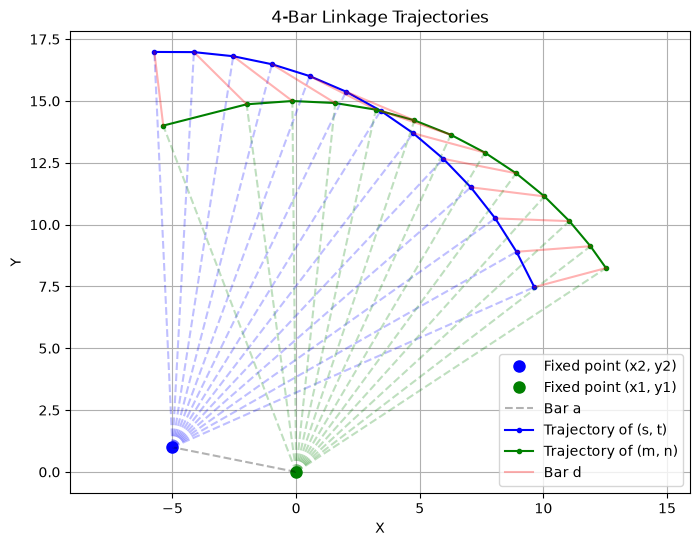

In [30]:
# INPUT HERE
b, d, e = 16.0, 3.0, 15.0
x_1, y_1 = 0.0, 0.0
x_2, y_2 = -5.0, 1.0

theta = np.arange(3.14 * 0.1, 3.14 * 0.8, 0.1)

a, theta_valid, s, t, c, angle_ah, angle_ch, omega, angle_eh, m, n, which_root, intersects, internal_ok, valid = trajectory(b, d, e, x_1, y_1, x_2, y_2, theta)
distance_d = check_trajectory(d, x_1, y_1, x_2, y_2, s, t, m, n)

if np.any(~valid):
    print(f'Skipped {np.count_nonzero(~valid)} unreachable theta value(s).')
    print(f'Valid theta range used for plotting: {theta_valid[0]:.3f} to {theta_valid[-1]:.3f}')

print(f'Max deviation from d = {d} is {np.max(np.abs(distance_d - d)):.2e}')
print(f'Root 1 count: {np.count_nonzero(which_root == 1)}')
print(f'Root 2 count: {np.count_nonzero(which_root == 2)}')
print(f'Intersection count (x2->st vs x1->mn): {np.count_nonzero(intersects)} / {len(intersects)}')
print(f'Internal-angle OK count: {np.count_nonzero(internal_ok)} / {len(internal_ok)}')

plt.figure(figsize=(8, 6))
plt.plot(x_2, y_2, 'bo', markersize=8, label='Fixed point (x2, y2)')
plt.plot(x_1, y_1, 'go', markersize=8, label='Fixed point (x1, y1)')
plt.plot([x_1, x_2], [y_1, y_2], 'k--', alpha=0.3, label='Bar a')

plt.plot(s, t, 'b.-', label='Trajectory of (s, t)')
plt.plot(m, n, 'g.-', label='Trajectory of (m, n)')

for i in range(len(s)):
    plt.plot([x_2, s[i]], [y_2, t[i]], 'b--', alpha=0.25)
    plt.plot([x_1, m[i]], [y_1, n[i]], 'g--', alpha=0.25)
    plt.plot([s[i], m[i]], [t[i], n[i]], 'r-', alpha=0.3)

plt.plot([], [], 'r-', alpha=0.3, label='Bar d')
plt.title('4-Bar Linkage Trajectories')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()